# Project 3: Secret Sharing
Bach Nguyen

This project explore 2 different Secure Multi-Party Computation (SMPC) approaches

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import phe.paillier as paillier
import time

## Setting up the random seed

In [2]:
# Setting the random seed
np.random.seed(42)
rng = np.random.default_rng(42)
def randomizer(n, min_val, max_val):
    """
    Generate a list of random integer values within a specified range.

    Input:
        n (int): Number of random integers to generate.
        min_val (int): The minimum possible integer value (inclusive).
        max_val (int): The maximum possible integer value (exclusive).

    Output:
        numpy.ndarray: An array of randomly generated integers 
                       uniformly distributed between min_val and max_val.
    """
    values = rng.integers(low = min_val, high = max_val, size = n)
    return values

## Function to calculate the mean with no encryption

In [3]:
def baseline_mean(n, min_val, max_val):
    """
    Compute the average (mean) of randomly generated integer values 
    as a non-encrypted baseline for performance comparison.

    Input:
        n (int): Number of random integers to generate.
        min_val (int): The minimum possible integer value (inclusive).
        max_val (int): The maximum possible integer value (exclusive).

    Output:
        float: The computation time (in seconds) required to calculate the mean.
    """
    # Generate the list
    temp_list = randomizer(n, min_val, max_val).tolist()
    
    # Get the start time
    t0 = time.perf_counter()

    # Calculate the mean
    average = np.mean(temp_list)

    # Get the end time
    t1 = time.perf_counter()
    
    # Calculate the final time
    computation_time = t1 - t0
    return computation_time

## Function to calculate the mean with additively homomorphic Paillier encryption scheme

In [4]:
def paillier_mean(n, min_val, max_val, public_key, private_key):
    """
    Compute the average (mean) of randomly generated integer values 
    using the Paillier homomorphic encryption scheme for secure computation.

    Input:
        n (int): Number of random integers to generate.
        min_val (int): The minimum possible integer value (inclusive).
        max_val (int): The maximum possible integer value (exclusive).
        public_key (PaillierPublicKey): Public key used for encryption.
        private_key (PaillierPrivateKey): Private key used for decryption.

    Output:
        float: The computation time (in seconds) required for encrypted mean calculation.
    """
    # Generate the list
    temp_list = randomizer(n, min_val, max_val).tolist()

    # Get the start time
    t0 = time.perf_counter()

    # Encrypt each value using the Paillier public key
    encrypted_values = []
    for i in temp_list:
        encrypted_values.append(public_key.encrypt(i))

    # Compute the encrypted sum (homomorphic addition)
    encrypted_sum = sum(encrypted_values)

    # Decrypt the result and compute the mean
    decrypted_sum = private_key.decrypt(encrypted_sum)
    average = decrypted_sum / n
    
    # Get the end time
    t1 = time.perf_counter()

    # Calculate the total computation time
    computation_time = t1 - t0
    return computation_time

## Functions to calculate the mean with Shamir's secret sharing

In [5]:
def shamir_share_generator(secret, party_count, threshold, min_val, max_val):
    """
    Generate secret shares using Shamir's Secret Sharing (SSS) scheme.

    Input:
        secret (int): The value to be secret-shared.
        party_count (int): Total number of parties (number of shares to generate).
        threshold (int): Minimum number of shares required to reconstruct the secret.
        min_val (int): Minimum random coefficient value for polynomial generation.
        max_val (int): Maximum random coefficient value for polynomial generation.

    Output:
        list of tuples: Each tuple contains (party_index, share_value).
    """
    # Generate random polynomial coefficients (secret + random terms)
    coeffs = [secret] + rng.integers(low = min_val, high = max_val, size = threshold - 1).tolist()
    
    # Generate shares by evaluating the polynomial at each party index
    shares = []
    for x in range(1, party_count + 1):
        y = sum(coeff * (x ** power) for power, coeff in enumerate(coeffs))
        shares.append((x, y))  # store (party index, share value)
    return shares 

def shamir_reconstruct_secret(shares, threshold):
    """
    Reconstruct the original secret from a subset of shares using Lagrange interpolation.

    Input:
        shares (list of tuples): A list of (x, y) pairs representing the shares.
        threshold (int): The minimum number of shares required for reconstruction.

    Output:
        int: The reconstructed secret value.
    """
    secret = 0
    for j, (xj, yj) in enumerate(shares[:threshold]):
        lj = 1
        for m, (xm, _) in enumerate(shares[:threshold]):
            if m != j:
                lj *= xm / (xm - xj)
        secret += yj * lj

    return round(secret) 

def shamir_mean(n, min_val, max_val, party_count, threshold):
    """
    Compute the average (mean) of randomly generated integer values 
    using Shamir's Secret Sharing (SSS) for secure computation.

    Input:
        n (int): Number of random integers to generate.
        min_val (int): The minimum possible integer value (inclusive).
        max_val (int): The maximum possible integer value (exclusive).
        party_count (int): Total number of parties to distribute shares to.
        threshold (int): Minimum number of shares required for reconstruction.

    Output:
        float: The computation time (in seconds) required for secure mean calculation.
    """
    # Generate random values
    temp_list = randomizer(n, min_val, max_val).tolist()
    reconstructed_list = []

    # Get the start time
    t0 = time.perf_counter()

    # Share and reconstruct each secret
    for i in temp_list:
        shares = shamir_share_generator(i, party_count, threshold, min_val, max_val)
        secret_reconstructed = shamir_reconstruct_secret(shares, threshold)
        reconstructed_list.append(secret_reconstructed)

    # Compute the mean from reconstructed secrets
    average = np.mean(reconstructed_list)

    # Get the end time
    t1 = time.perf_counter()

    # Calculate total computation time
    computation_time = t1 - t0
    return computation_time

## Testing Function

In [6]:
def full_test(n_list, min_val, max_val, public_key, private_key, party_count, threshold):
    """
    Run performance comparison tests across Baseline, Paillier, and Shamir mean computations.

    Input:
        n_list (list of int): List of sample sizes (number of random integers) to test.
        min_val (int): Minimum integer value for random number generation.
        max_val (int): Maximum integer value for random number generation.
        public_key (PaillierPublicKey): Public key used for Paillier encryption.
        private_key (PaillierPrivateKey): Private key used for Paillier decryption.
        party_count (int): Total number of parties in Shamir's Secret Sharing.
        threshold (int): Minimum number of shares required for reconstruction in Shamir.

    Output:
        pandas.DataFrame: A DataFrame containing columns:
            - "n" (sample size)
            - "Baseline" (runtime in seconds)
            - "Paillier" (runtime in seconds)
            - "Shamir" (runtime in seconds)
    """
    results = []

    # Iterate through each sample size to test scalability
    for n in n_list:
        # Baseline (no encryption)
        baseline_time = baseline_mean(n, min_val, max_val)

        # Paillier Encryption-based mean computation
        paillier_time = paillier_mean(n, min_val, max_val, public_key, private_key)

        # Shamir Secret Sharing-based mean computation
        shamir_time = shamir_mean(n, min_val, max_val, party_count, threshold)

        # Store all results for this sample size
        results.append({
            "n": n,
            "Baseline": baseline_time,
            "Paillier": paillier_time,
            "Shamir": shamir_time
        })

    # Convert the list of results into a pandas DataFrame
    df_results = pd.DataFrame(results)
    return df_results

## Setting up the parameters, running the code, and displaying it with a graph

In [7]:
# n list setup
n_list = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]

# integer range setup
min_val = 0
max_val = 1000000

# Paillier keys setup
public_key, private_key = paillier.generate_paillier_keypair()

# Party and threshold setup
party_count = 10
threshold = party_count // 2

# Running the test
df_results = full_test(n_list, min_val, max_val, public_key, private_key, party_count, threshold)

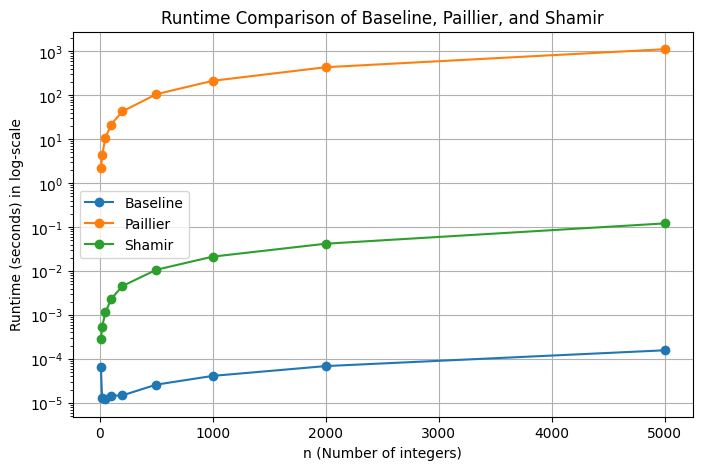

In [13]:
# Generate the plot in log-scale
plt.figure(figsize=(8, 5))
for method in ["Baseline", "Paillier", "Shamir"]:
    plt.plot(df_results["n"], df_results[method], marker='o', label=method)

plt.xlabel("n (Number of integers)")
plt.ylabel("Runtime (seconds) in log-scale")
plt.yscale('log')
plt.title("Runtime Comparison of Baseline, Paillier, and Shamir")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Final Results
df_results

,n,Baseline,Paillier,Shamir
0,10,0.000064,2.175277,0.000279
1,20,0.000013,4.301557,0.000538
2,50,0.000012,10.775478,0.001148
3,100,0.000014,21.634102,0.002302
4,200,0.000015,43.043939,0.004559
5,500,0.000026,105.900891,0.010697
6,1000,0.000041,213.991650,0.021294
7,2000,0.000069,435.664255,0.041893
8,5000,0.000157,1118.591460,0.121451
